# Explicação Breve do Projeto
- Importação dos dados de FIDC pelo portal do CVM (Comissão de Valores Moobiliários) entre os meses de Setembro, Outubro e Novembro, para analisar anomalias nas transações desse fundo de investimento.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Criar um filtro para identificar as empresas envolvidas

In [ ]:
# --- PASSO 1: CONFIGURAÇÃO COM A NOVA TABELA ---
import pandas as pd
import numpy as np

# 1. Carregar a nova tabela (Aba de CNPJs e Raízes)
# Use o nome exato do arquivo que você subiu no Colab
caminho_csv = '/content/drive/MyDrive/dados-master/CNPJs_atualizado.xlsx'
df_relacoes = pd.read_excel(caminho_csv)

# 2. Criar dicionários de inteligência: Raiz -> Instituição e Raiz -> Status
# O .zfill(8) é vital para não perder os zeros à esquerda (ex: Reag 00360305)
mapeamento_grupos = dict(zip(
    df_relacoes['Raiz (8 dígitos)'].astype(str).str.zfill(8),
    df_relacoes['Instituição']
))

mapeamento_status = dict(zip(
    df_relacoes['Raiz (8 dígitos)'].astype(str).str.zfill(8),
    df_relacoes['Status / Situação Atual']
))

def identificar_grupo(cnpj):
    if pd.isna(cnpj): return 'Mercado'
    raiz = str(cnpj)[:8].zfill(8)
    return mapeamento_grupos.get(raiz, 'Mercado')

def identificar_status(cnpj):
    if pd.isna(cnpj): return 'Normal'
    raiz = str(cnpj)[:8].zfill(8)
    return mapeamento_status.get(raiz, 'Normal')

def limpar_cnpj(cnpj):
    return ''.join(filter(str.isdigit, str(cnpj))).zfill(14)

# 2. Pipeline de Extração Organizada (ETL)

In [ ]:
import os
import glob

caminho_base = '/content/drive/MyDrive/dados-master'
# O padrão busca especificamente as pastas de 2025 (de 03 a 11)
padrao_arquivos = os.path.join(caminho_base, 'inf_mensal_fidc_2025*', '*tab_*.csv')
arquivos = glob.glob(padrao_arquivos)

# Dicionário para organizar os dados por tipo de tabela
tabelas_consolidadas = {}

print(f"Iniciando a leitura de {len(arquivos)} arquivos...")

for arq in arquivos:
    nome_base = os.path.basename(arq)
    partes = nome_base.split('_')
    try:
        idx_tab = partes.index('tab')
        tipo_tab = f"{partes[idx_tab]}_{partes[idx_tab+1]}"
        # Caso especial para as tabelas da série X que possuem sub-índices (X.1, X.3, etc)
        if tipo_tab == 'tab_X' and len(partes) > idx_tab + 2 and partes[idx_tab+2].isdigit():
            tipo_tab = f"tab_X_{partes[idx_tab+2]}"
    except (ValueError, IndexError):
        tipo_tab = 'outros'

    # Leitura do CSV com as configurações da CVM
    df_temp = pd.read_csv(arq, sep=';', encoding='iso-8859-1', low_memory=False)

    # --- NORMALIZAÇÃO IMEDIATA (Essencial para o Merge futuro) ---

    # 1. Padronizar CNPJs (Remove pontos, barras e traços)
    if 'CNPJ_FUNDO_CLASSE' in df_temp.columns:
        df_temp['CNPJ_FUNDO_CLASSE'] = df_temp['CNPJ_FUNDO_CLASSE'].apply(limpar_cnpj)

    if 'CNPJ_FUNDO' in df_temp.columns: # Nome usado em algumas tabelas da série X
        df_temp['CNPJ_FUNDO'] = df_temp['CNPJ_FUNDO'].apply(limpar_cnpj)

    if 'CNPJ_ADMIN' in df_temp.columns:
        df_temp['CNPJ_ADMIN'] = df_temp['CNPJ_ADMIN'].apply(limpar_cnpj)

    # 2. Padronizar Datas (Transforma string em objeto datetime)
    if 'DT_COMPTC' in df_temp.columns:
        df_temp['DT_COMPTC'] = pd.to_datetime(df_temp['DT_COMPTC'])

    # Agrupar no dicionário
    if tipo_tab not in tabelas_consolidadas:
        tabelas_consolidadas[tipo_tab] = []
    tabelas_consolidadas[tipo_tab].append(df_temp)

# Concatenar todos os meses de cada categoria em um único DataFrame
print("\n--- Resumo da Consolidação de 2025 ---")
for tipo in sorted(tabelas_consolidadas.keys()):
    tabelas_consolidadas[tipo] = pd.concat(tabelas_consolidadas[tipo], ignore_index=True)
    print(f"Tabela {tipo.ljust(8)} | Total de Linhas: {len(tabelas_consolidadas[tipo])}")

print("\nPasso 2 concluído com sucesso!")

Iniciando a leitura de 153 arquivos...

--- Resumo da Consolidação de 2025 ---
Tabela tab_I    | Total de Linhas: 29876
Tabela tab_II   | Total de Linhas: 29876
Tabela tab_III  | Total de Linhas: 29876
Tabela tab_IV   | Total de Linhas: 29876
Tabela tab_IX   | Total de Linhas: 29876
Tabela tab_V    | Total de Linhas: 29876
Tabela tab_VI   | Total de Linhas: 29876
Tabela tab_VII  | Total de Linhas: 29876
Tabela tab_X    | Total de Linhas: 29876
Tabela tab_X_1  | Total de Linhas: 128499
Tabela tab_X_2  | Total de Linhas: 98324
Tabela tab_X_3  | Total de Linhas: 98253
Tabela tab_X_4  | Total de Linhas: 372198
Tabela tab_X_5  | Total de Linhas: 29876
Tabela tab_X_6  | Total de Linhas: 95700
Tabela tab_X_7  | Total de Linhas: 29876

Passo 2 concluído com sucesso!


# 3. O "Master Join" (Transformação)

In [ ]:
# --- PASSO 3 FINAL — baseado nos metadados oficiais da CVM ---

chaves = ['CNPJ_FUNDO_CLASSE', 'DT_COMPTC']

# 1. Base: Tab I + Tab IV
df_master = pd.merge(
    tabelas_consolidadas['tab_I'][[
        'CNPJ_FUNDO_CLASSE', 'DT_COMPTC', 'CNPJ_ADMIN', 'DENOM_SOCIAL',
        'TAB_I2A2_VL_CRED_VENC_INAD',
        'TAB_I2A3_VL_CRED_INAD',
        'TAB_I2B2_VL_CRED_VENC_INAD',
        'TAB_I2B3_VL_CRED_INAD',
        'TAB_I2A12_CPF_CNPJ_CEDENTE_1',
        'TAB_I2A12_CPF_CNPJ_CEDENTE_2',
        'TAB_I2A12_CPF_CNPJ_CEDENTE_3',
        'TAB_I2A12_PR_CEDENTE_1',
    ]],
    tabelas_consolidadas['tab_IV'][chaves + ['TAB_IV_A_VL_PL']],
    on=chaves, how='left'
)

# 2. Tab VII
df_master = pd.merge(
    df_master,
    tabelas_consolidadas['tab_VII'][chaves + [
        'TAB_VII_A1_2_VL_DIRCRED_RISCO',
        'TAB_VII_A2_2_VL_DIRCRED_SEM_RISCO',
        'TAB_VII_C_2_VL_SUBST',
        'TAB_VII_D_2_VL_RECOMPRA',
        'TAB_VII_B1_2_VL_CEDENTE',
    ]],
    on=chaves, how='left'
)

# 3. Tab X.5
if 'tab_X_5' in tabelas_consolidadas:
    df_master = pd.merge(
        df_master,
        tabelas_consolidadas['tab_X_5'][chaves + [
            'TAB_X_VL_LIQUIDEZ_0',
            'TAB_X_VL_LIQUIDEZ_30',
            'TAB_X_VL_LIQUIDEZ_MAIOR_360',
        ]],
        on=chaves, how='left'
    )

# 4. Tab X.6
if 'tab_X_6' in tabelas_consolidadas:
    cols_x6 = tabelas_consolidadas['tab_X_6'].columns
    col_cnpj_x6 = 'CNPJ_FUNDO' if 'CNPJ_FUNDO' in cols_x6 else 'CNPJ_FUNDO_CLASSE'
    df_x6 = tabelas_consolidadas['tab_X_6'].copy()
    df_x6[col_cnpj_x6] = df_x6[col_cnpj_x6].apply(limpar_cnpj)
    df_x6['TAB_X_PR_DESVIO_DESEMP'] = (
        pd.to_numeric(df_x6['TAB_X_PR_DESEMP_REAL'].astype(str).str.replace(',','.'), errors='coerce') -
        pd.to_numeric(df_x6['TAB_X_PR_DESEMP_ESPERADO'].astype(str).str.replace(',','.'), errors='coerce')
    ).abs()
    df_x6_agg = df_x6.groupby([col_cnpj_x6, 'DT_COMPTC'], as_index=False)['TAB_X_PR_DESVIO_DESEMP'].max()
    df_master = pd.merge(df_master, df_x6_agg,
                         left_on=['CNPJ_FUNDO_CLASSE', 'DT_COMPTC'],
                         right_on=[col_cnpj_x6, 'DT_COMPTC'], how='left')
    if col_cnpj_x6 != 'CNPJ_FUNDO_CLASSE':
        df_master.drop(columns=[col_cnpj_x6], inplace=True, errors='ignore')

# 5. Tab X.3
if 'tab_X_3' in tabelas_consolidadas:
    df_x3 = tabelas_consolidadas['tab_X_3'].copy()
    col_cnpj_x3 = 'CNPJ_FUNDO' if 'CNPJ_FUNDO' in df_x3.columns else 'CNPJ_FUNDO_CLASSE'
    df_x3[col_cnpj_x3] = df_x3[col_cnpj_x3].apply(limpar_cnpj)
    df_x3['VL_COTA_NUM'] = pd.to_numeric(
        df_x3['TAB_X_VL_RENTAB_MES'].astype(str).str.replace(',', '.'), errors='coerce'
    )
    df_x3 = df_x3[df_x3['VL_COTA_NUM'].between(0.50, 100_000)].copy()
    df_x3_agg = (
        df_x3[df_x3['TAB_X_CLASSE_SERIE'].str.contains('Senior', case=False, na=False)]
        .groupby([col_cnpj_x3, 'DT_COMPTC'], as_index=False)['VL_COTA_NUM'].max()
    )
    df_x3_agg = df_x3_agg.sort_values([col_cnpj_x3, 'DT_COMPTC'])
    df_x3_agg['TAB_X_VL_RENTAB_MES'] = (
        df_x3_agg.groupby(col_cnpj_x3)['VL_COTA_NUM'].pct_change(fill_method=None)
    )
    df_x3_agg.loc[df_x3_agg['TAB_X_VL_RENTAB_MES'].abs() > 0.30, 'TAB_X_VL_RENTAB_MES'] = np.nan
    df_master = df_master.drop(columns=['TAB_X_VL_RENTAB_MES'], errors='ignore')
    df_master = pd.merge(df_master,
                         df_x3_agg[[col_cnpj_x3, 'DT_COMPTC', 'TAB_X_VL_RENTAB_MES']],
                         left_on=['CNPJ_FUNDO_CLASSE', 'DT_COMPTC'],
                         right_on=[col_cnpj_x3, 'DT_COMPTC'], how='left')
    if col_cnpj_x3 != 'CNPJ_FUNDO_CLASSE':
        df_master.drop(columns=[col_cnpj_x3], inplace=True, errors='ignore')

# 6. Normalizar colunas numericas
cols_numericas = [
    'TAB_VII_A1_2_VL_DIRCRED_RISCO', 'TAB_VII_A2_2_VL_DIRCRED_SEM_RISCO',
    'TAB_VII_C_2_VL_SUBST', 'TAB_VII_D_2_VL_RECOMPRA', 'TAB_VII_B1_2_VL_CEDENTE',
    'TAB_I2A2_VL_CRED_VENC_INAD', 'TAB_I2A3_VL_CRED_INAD',
    'TAB_I2B2_VL_CRED_VENC_INAD', 'TAB_I2B3_VL_CRED_INAD',
]
for col in cols_numericas:
    if col in df_master.columns:
        df_master[col] = pd.to_numeric(
            df_master[col].astype(str).str.replace(',', '.'), errors='coerce'
        ).fillna(0)

# 7. Mapeamento de grupos em cascata
df_master['grupo_economico'] = df_master['CNPJ_ADMIN'].apply(identificar_grupo)

mask = df_master['grupo_economico'] == 'Mercado'
df_master.loc[mask, 'grupo_economico'] = (
    df_master.loc[mask, 'CNPJ_FUNDO_CLASSE'].apply(identificar_grupo)
)

for col_ced in ['TAB_I2A12_CPF_CNPJ_CEDENTE_1',
                'TAB_I2A12_CPF_CNPJ_CEDENTE_2',
                'TAB_I2A12_CPF_CNPJ_CEDENTE_3']:
    if col_ced in df_master.columns:
        mask = df_master['grupo_economico'] == 'Mercado'
        df_master.loc[mask, 'grupo_economico'] = (
            df_master.loc[mask, col_ced]
            .apply(lambda x: identificar_grupo(
                str(int(float(x))).zfill(14) if pd.notna(x) and float(x) > 0 else None
            ))
        )

# 8. Features originais
pl = df_master['TAB_IV_A_VL_PL']

df_master['movimentacao_total_taxa'] = np.where(
    pl > 0,
    (df_master['TAB_VII_A1_2_VL_DIRCRED_RISCO']
     + df_master['TAB_VII_A2_2_VL_DIRCRED_SEM_RISCO']
     + df_master['TAB_VII_C_2_VL_SUBST']
     + df_master['TAB_VII_D_2_VL_RECOMPRA']) / pl,
    0
)

df_master['vl_inad_total'] = (
    df_master['TAB_I2A2_VL_CRED_VENC_INAD']
    + df_master['TAB_I2A3_VL_CRED_INAD']
    + df_master['TAB_I2B2_VL_CRED_VENC_INAD']
    + df_master['TAB_I2B3_VL_CRED_INAD']
)
df_master['taxa_inadimplencia'] = np.where(pl > 0, df_master['vl_inad_total'] / pl, 0)

df_master['concentracao_cedente'] = pd.to_numeric(
    df_master['TAB_I2A12_PR_CEDENTE_1'].astype(str).str.replace(',', '.'),
    errors='coerce'
).fillna(0)

# 9. Features adicionais
df_master['taxa_aquisicao'] = np.where(
    pl > 0,
    (df_master['TAB_VII_A1_2_VL_DIRCRED_RISCO']
     + df_master['TAB_VII_A2_2_VL_DIRCRED_SEM_RISCO']) / pl,
    0
)

df_master['taxa_devolucao_cedente'] = np.where(
    pl > 0,
    df_master['TAB_VII_B1_2_VL_CEDENTE'] / pl,
    0
)

df_master['ratio_inad_giro'] = np.where(
    df_master['movimentacao_total_taxa'] > 0,
    df_master['taxa_inadimplencia'] / df_master['movimentacao_total_taxa'],
    0
)

# --- NOVAS FEATURES DE COMBATE À "ESTABILIDADE ARTIFICIAL" ---
# Vamos calcular o desvio padrão (volatilidade) de cada fundo ao longo dos meses

# Ordenar por data para garantir a cronologia
df_master = df_master.sort_values(['CNPJ_FUNDO_CLASSE', 'DT_COMPTC'])

# 1. Volatilidade da Inadimplência (O crime da suavização)
df_master['volatilidade_inad'] = (
    df_master.groupby('CNPJ_FUNDO_CLASSE')['taxa_inadimplencia']
    .transform('std')
    .fillna(0) # Se tiver só 1 mês, a volatilidade é 0
)

# 2. Volatilidade da Taxa de Aquisição
df_master['volatilidade_aquisicao'] = (
    df_master.groupby('CNPJ_FUNDO_CLASSE')['taxa_aquisicao']
    .transform('std')
    .fillna(0)
)

# 3. Trava de imobilidade (O fundo congela os números de propósito?)
# Verifica se a inadimplência do mês atual é EXATAMENTE igual a do mês passado
df_master['inad_congelada'] = (
    df_master.groupby('CNPJ_FUNDO_CLASSE')['taxa_inadimplencia']
    .diff() == 0
).astype(int)


# Limpeza final
n_antes = len(df_master)
df_master = df_master[df_master['TAB_IV_A_VL_PL'] >= 1_000].copy()
print(f"Removidos por PL < R$ 1.000: {n_antes - len(df_master):,} registros")

df_master.loc[df_master['concentracao_cedente'] > 100, 'concentracao_cedente'] = np.nan
df_master['concentracao_cedente'] = df_master['concentracao_cedente'].fillna(0)
df_master.loc[df_master['ratio_inad_giro'] > 100, 'ratio_inad_giro'] = 0

Removidos por PL < R$ 1.000: 787 registros


- Salvar o CSV de Dados FIDC

In [ ]:
# SALVAMENTO DO CSV
caminho_salvamento = '/content/drive/MyDrive/dados-master/df_master_fidc_2025.csv'
df_master.to_csv(caminho_salvamento, sep=';', index=False, encoding='utf-8-sig')
print(f"Arquivo salvo em: {caminho_salvamento}")

Arquivo salvo em: /content/drive/MyDrive/dados-master/df_master_fidc_2025.csv


#4. Engenharia de Atributos e Detecção de Anomalias

In [ ]:
!pip install catboost -q

In [ ]:
from catboost import CatBoostClassifier
from sklearn.preprocessing import RobustScaler
from scipy.stats import ks_2samp
import pandas as pd
import numpy as np

features = [
    'taxa_aquisicao',
    'taxa_devolucao_cedente',
    'taxa_inadimplencia',
    'concentracao_cedente',
    'ratio_inad_giro',
    'volatilidade_inad',
    'volatilidade_aquisicao',
    'inad_congelada'
]

# 1. Filtro de linhas validas — PL >= 1 milhao
mask_valido = df_master[features].notna().all(axis=1)
mask_valido &= df_master['TAB_IV_A_VL_PL'] >= 1_000_000

X_clean = df_master.loc[mask_valido, features].copy()
print(f"Linhas validas (PL >= 1M): {mask_valido.sum():,}")
print(f"Descartadas              : {(~mask_valido).sum():,}")

# 2. Mascaras de treino
# Mercado ativo = negativos (normais) — exclui zumbis com giro < 1%
mask_fundos_ativos = df_master.loc[mask_valido, 'movimentacao_total_taxa'] > 0.01
mask_mercado       = (df_master.loc[mask_valido, 'grupo_economico'] == 'Mercado') & mask_fundos_ativos
mask_investigado   = df_master.loc[mask_valido, 'grupo_economico'] != 'Mercado'

print(f"\nTreino — Mercado ativo : {mask_mercado.sum():,}")
print(f"Treino — Investigados  : {mask_investigado.sum():,}")

# 3. Teto logico (evita explosoes por erros de PL da CVM)
p95_vol_inad = X_clean.loc[mask_mercado, 'volatilidade_inad'].quantile(0.95)
p95_vol_aq   = X_clean.loc[mask_mercado, 'volatilidade_aquisicao'].quantile(0.95)

X_clean['volatilidade_inad']      = X_clean['volatilidade_inad'].clip(upper=min(p95_vol_inad, 1.0))
X_clean['volatilidade_aquisicao'] = X_clean['volatilidade_aquisicao'].clip(upper=min(p95_vol_aq, 1.0))
X_clean['taxa_inadimplencia']     = X_clean['taxa_inadimplencia'].clip(upper=1.0)
X_clean['ratio_inad_giro']        = X_clean['ratio_inad_giro'].clip(upper=5.0)

# 4. Scaler — RobustScaler focado na mediana do mercado
scaler = RobustScaler()
scaler.fit(X_clean[mask_mercado])
X_scaled_arr = scaler.transform(X_clean)
X_scaled = pd.DataFrame(X_scaled_arr, index=X_clean.index, columns=features)

# 5. TARGET supervisionado
# 1 = investigado (anomalia conhecida) | 0 = mercado ativo (normal)
df_master['TARGET'] = 0
df_master.loc[mask_valido & mask_investigado, 'TARGET'] = 1

y_treino = df_master.loc[mask_valido, 'TARGET']

# 6. Balancear classes — mercado e muito maior que investigados
n_pos = int(y_treino.sum())
n_neg = int((y_treino == 0).sum())
scale_pos_weight = n_neg / n_pos
print(f"\nBalanceamento — Mercado: {n_neg:,} | Investigados: {n_pos:,}")
print(f"scale_pos_weight aplicado: {scale_pos_weight:.1f}x")

# 7. Treinar o CatBoost supervisionado
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=scale_pos_weight,
    eval_metric='AUC',
    random_seed=42,
    verbose=100,
)
cb_model.fit(X_scaled, y_treino)

# 8. Score = probabilidade de ser investigado (anomalia)
probs = cb_model.predict_proba(X_scaled)[:, 1]

# 9. Gravar no df_master
df_master['anomaly_flag']   = np.nan
df_master['anomaly_score']  = np.nan
df_master['grau_suspeicao'] = np.nan
df_master['is_anomalia']    = 0

df_master.loc[mask_valido, 'anomaly_score']  = probs
df_master.loc[mask_valido, 'grau_suspeicao'] = probs
df_master.loc[mask_valido, 'anomaly_flag']   = (probs >= 0.50).astype(int)
df_master.loc[mask_valido, 'is_anomalia']    = (probs >= 0.50).astype(int)

# 10. Diagnostico de performance (KS + distribuicao por decil)
print("\n" + "="*50)
print(" RESULTADOS DO CATBOOST SUPERVISIONADO")
print("="*50)

score_mercado  = df_master.loc[mask_valido & mask_mercado,     'anomaly_score']
score_investig = df_master.loc[mask_valido & mask_investigado, 'anomaly_score']

ks_stat, p_value = ks_2samp(score_mercado, score_investig)
print(f"\n[1] TESTE KS (Kolmogorov-Smirnov):")
print(f"Estatistica KS : {ks_stat:.4f}")
print(f"P-Value        : {p_value:.4e}")

df_valid = df_master[mask_valido].copy()
df_valid['decil'] = pd.qcut(df_valid['anomaly_score'], 10, labels=False, duplicates='drop')

total_investigados = (df_valid['grupo_economico'] != 'Mercado').sum()
dist_investigados  = df_valid[df_valid['grupo_economico'] != 'Mercado'].groupby('decil').size()

print(f"\n[2] DISTRIBUICAO DOS ALVOS (Total: {total_investigados} registros):")
print("Decil 9 = Top 10% mais suspeitos | Decil 0 = Top 10% mais normais\n")

dist_perc = (dist_investigados / total_investigados * 100).round(2)
for decil in sorted(df_valid['decil'].unique(), reverse=True):
    perc     = dist_perc.get(decil, 0.0)
    marcador = " <--- ALVO AQUI"    if decil >= 8 and perc > 15 else ""
    marcador = " <--- ALARME FALSO" if decil <= 1 and perc > 40 else marcador
    print(f"Decil {decil}: {perc:>5.2f}% dos investigados{marcador}")

print("\n[3] IMPORTANCIA DAS FEATURES (CatBoost nativo):")
importancias = pd.Series(
    cb_model.get_feature_importance(),
    index=features
).sort_values(ascending=False)
for feat, imp in importancias.items():
    print(f"  {feat:<35} {imp:.2f}%")

print("\n--- Top 10 fundos mais suspeitos ---")
ranking = (
    df_master[mask_valido]
    .groupby(['DENOM_SOCIAL', 'grupo_economico'])['anomaly_score']
    .mean()
    .reset_index()
    .nlargest(10, 'anomaly_score')
)
print(ranking.to_string(index=False))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
Linhas validas (PL >= 1M): 28,370
Descartadas              : 845

Treino — Mercado ativo : 11,346
Treino — Investigados  : 2,751

Balanceamento — Mercado: 25,619 | Investigados: 2,751
scale_pos_weight aplicado: 9.3x
0:	total: 85.3ms	remaining: 42.6s
100:	total: 2.58s	remaining: 10.2s
200:	total: 5.27s	remaining: 7.84s
300:	total: 7.12s	remaining: 4.7s
400:	total: 8.02s	remaining: 1.98s
499:	total: 8.91s	remaining: 0us

 RESULTADOS DO CATBOOST SUPERVISIONADO

[1] TESTE KS (Kolmogorov-Smirnov):
Estatistica KS : 0.9616
P-Value        : 0.0000e+00

[2] DISTRIBUICAO DOS ALVOS (Total: 2751 registros):
Decil 9 = Top 10% mais suspeitos | Decil 0 = Top 10% mais normais

Decil 7: 47.11% dos investigados
Decil 6:  7.38% dos investigados
Decil 5: 45.15% dos investigados
Decil 4:  0.29% dos investigados
Decil 3:  0.07% dos investigados
Decil 2:  0.00% dos investigados
Decil 1:  0.00% dos investigados
Decil 0:  0.00% dos i

# 5. Validação e Explicabilidade (CatBoost + SHAP)

In [ ]:
!pip install shap -q

 RAIO-X DE PERFORMANCE DO CATBOOST SUPERVISIONADO

[A] METRICAS DE SEPARACAO:
ROC-AUC Score : 0.8852  (>0.90 e excelente)
PR-AUC Score  : 0.5308  (>0.60 e nivel industrial)

[B] OPERACAO REAL (investigar so quem tirou > 0.85):
Verdadeiros Negativos (inocentes ignorados)        : 25593
Falsos Positivos (alarmes falsos)                  : 26
Falsos Negativos (fraudes que escaparam)           : 2335
Verdadeiros Positivos (fraudes pegas em flagrante) : 416

Precisao da Operacao: 94.1%

[C] EXPLICABILIDADE FORENSE (SHAP):


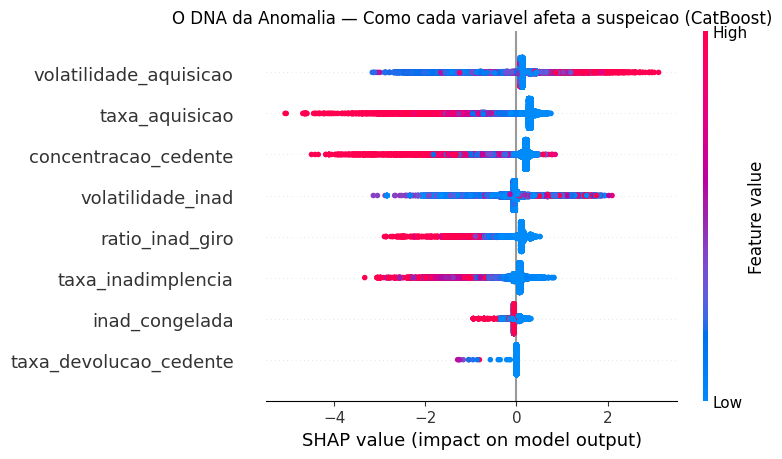

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
import shap
import matplotlib.pyplot as plt

print("="*50)
print(" RAIO-X DE PERFORMANCE DO CATBOOST SUPERVISIONADO")
print("="*50)

y_true  = df_master.loc[mask_valido, 'TARGET']
y_probs = df_master.loc[mask_valido, 'anomaly_score']

# A. Metricas globais
roc_auc = roc_auc_score(y_true, y_probs)
pr_auc  = average_precision_score(y_true, y_probs)

print(f"\n[A] METRICAS DE SEPARACAO:")
print(f"ROC-AUC Score : {roc_auc:.4f}  (>0.90 e excelente)")
print(f"PR-AUC Score  : {pr_auc:.4f}  (>0.60 e nivel industrial)")

# B. Matriz de confusao com corte 0.85
corte_auditoria = 0.85
y_pred_rigoroso = (y_probs >= corte_auditoria).astype(int)
cm = confusion_matrix(y_true, y_pred_rigoroso)

precisao = cm[1][1] / (cm[1][1] + cm[0][1]) if (cm[1][1] + cm[0][1]) > 0 else 0

print(f"\n[B] OPERACAO REAL (investigar so quem tirou > {corte_auditoria}):")
print(f"Verdadeiros Negativos (inocentes ignorados)        : {cm[0][0]}")
print(f"Falsos Positivos (alarmes falsos)                  : {cm[0][1]}")
print(f"Falsos Negativos (fraudes que escaparam)           : {cm[1][0]}")
print(f"Verdadeiros Positivos (fraudes pegas em flagrante) : {cm[1][1]}")
print(f"\nPrecisao da Operacao: {precisao*100:.1f}%")

# C. SHAP — explicabilidade nativa do CatBoost
print("\n[C] EXPLICABILIDADE FORENSE (SHAP):")

explainer   = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_scaled)

plt.figure(figsize=(10, 6))
plt.title("O DNA da Anomalia — Como cada variavel afeta a suspeicao (CatBoost)")
shap.summary_plot(shap_values, X_scaled, show=False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dados-master/shap_catboost.png', dpi=150, bbox_inches='tight')
plt.show()


# 5. Gráficos

### Gráfico 1 — Evolução temporal do excesso de suspeição

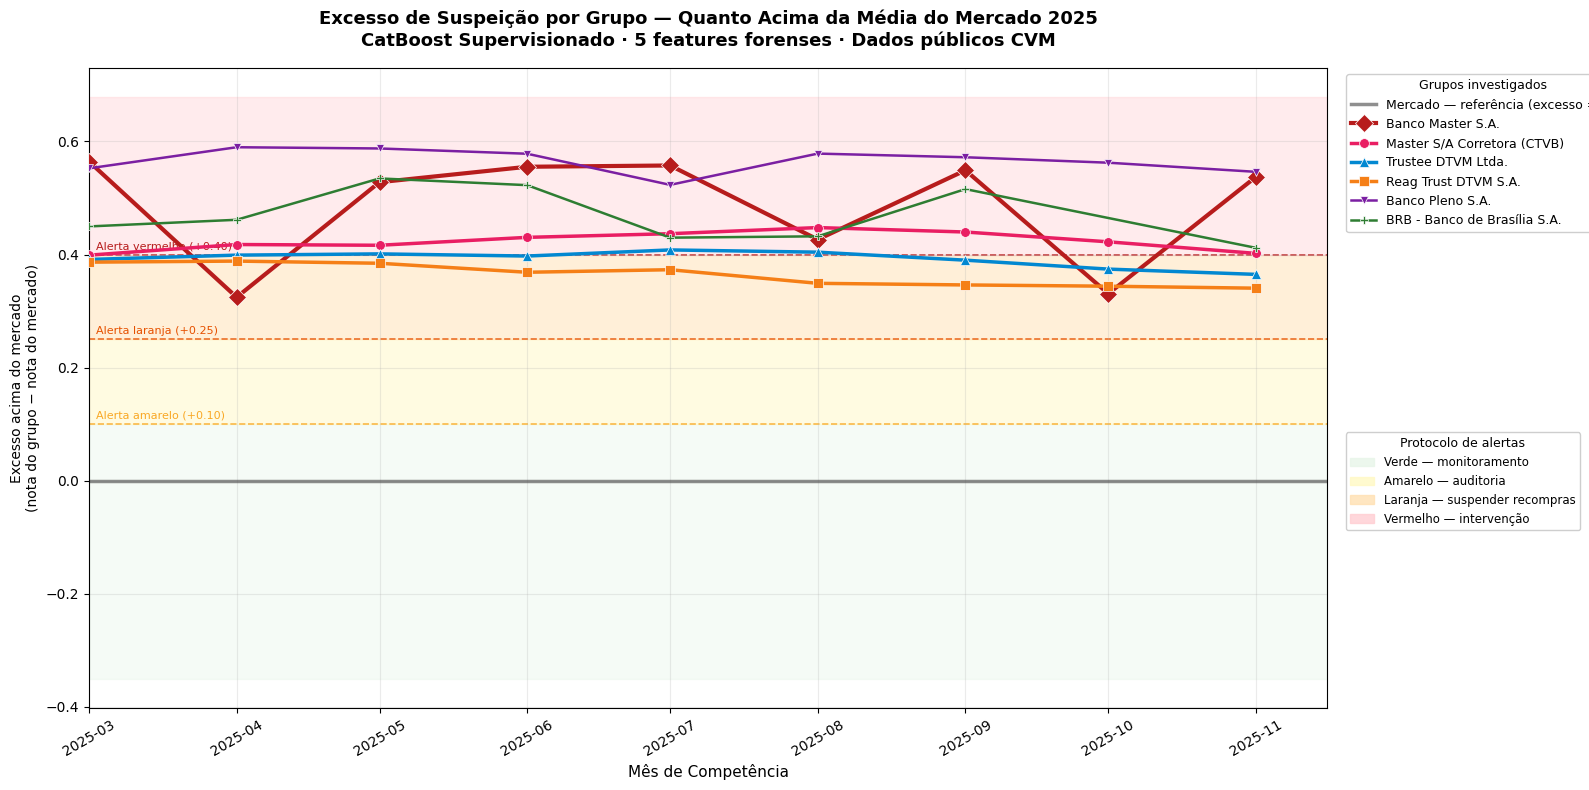

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── 1. Calcular baseline e excesso ANTES de qualquer plot ────────────────────
baseline = (df_master[df_master['grupo_economico'] == 'Mercado']
            .groupby('DT_COMPTC')['grau_suspeicao'].mean())

df_master['excesso'] = (
    df_master['grau_suspeicao']
    - df_master['DT_COMPTC'].map(baseline).fillna(0)
)

# ── 2. Séries mensais por grupo ──────────────────────────────────────────────
grupos_cfg = {
    'Banco Master S.A.'           : ('#B71C1C', 'D', 3.0, 9),
    'Master S/A Corretora (CTVB)' : ('#E91E63', 'o', 2.5, 7),
    'Trustee DTVM Ltda.'          : ('#0288D1', '^', 2.5, 7),
    'Reag Trust DTVM S.A.'        : ('#F57F17', 's', 2.5, 7),
    'Banco Pleno S.A.'            : ('#7B1FA2', 'v', 1.8, 6),
    'BRB - Banco de Brasília S.A.': ('#2E7D32', 'P', 1.8, 6),
}

evolucao = (
    df_master[df_master['grupo_economico'].isin(grupos_cfg.keys())]
    .groupby([df_master['DT_COMPTC'].dt.to_period('M'), 'grupo_economico'])
    ['excesso'].mean().unstack()
)
evolucao.index = evolucao.index.to_timestamp()

# ── 3. Limites do eixo Y — definir ANTES de qualquer elemento visual ─────────
ylim_bot = min(evolucao.min().min() * 1.15, -0.35)
ylim_top = max(evolucao.max().max() * 1.15,  0.55)
x_inicio = evolucao.index[0]   # âncora X para textos de threshold

# ── 4. Figura ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))

ax.set_xlim(evolucao.index[0], evolucao.index[-1] + pd.DateOffset(days=15))

# Faixas de alerta
ax.axhspan(ylim_bot, 0.10,    color='#E8F5E9', alpha=0.4, zorder=0)
ax.axhspan(0.10,     0.25,    color='#FFF9C4', alpha=0.5, zorder=0)
ax.axhspan(0.25,     0.40,    color='#FFE0B2', alpha=0.5, zorder=0)
ax.axhspan(0.40,     ylim_top, color='#FFCDD2', alpha=0.4, zorder=0)

# Linhas e rótulos de threshold
for nivel, cor, rotulo in [
    (0.10, '#F9A825', 'Alerta amarelo (+0.10)'),
    (0.25, '#E65100', 'Alerta laranja (+0.25)'),
    (0.40, '#B71C1C', 'Alerta vermelho (+0.40)'),
]:
    ax.axhline(nivel, color=cor, linestyle='--', linewidth=1.2,
               alpha=0.8, zorder=1)
    ax.text(x_inicio, nivel + 0.006,
            f'  {rotulo}', fontsize=8, color=cor,
            va='bottom', zorder=3)

# Linha do mercado = zero
ax.axhline(0, color='#444444', linestyle='-', linewidth=2.5,
           alpha=0.6, label='Mercado — referência (excesso = 0)', zorder=2)

# ── 5. Plotar grupos ─────────────────────────────────────────────────────────
for grupo, (cor, mk, lw, ms) in grupos_cfg.items():
    if grupo not in evolucao.columns:
        continue
    serie = evolucao[grupo].dropna()
    ax.plot(serie.index, serie.values,
            color=cor, linewidth=lw,
            marker=mk, markersize=ms,
            label=grupo, zorder=5,
            markeredgecolor='white', markeredgewidth=0.5)


# ── 6. Legendas das faixas ───────────────────────────────────────────────────
patches_faixas = [
    mpatches.Patch(color='#E8F5E9', alpha=0.8, label='Verde — monitoramento'),
    mpatches.Patch(color='#FFF9C4', alpha=0.8, label='Amarelo — auditoria'),
    mpatches.Patch(color='#FFE0B2', alpha=0.8, label='Laranja — suspender recompras'),
    mpatches.Patch(color='#FFCDD2', alpha=0.8, label='Vermelho — intervenção'),
]

leg1 = ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0),
                 fontsize=9, title='Grupos investigados',
                 title_fontsize=9, framealpha=0.95)
leg2 = ax.legend(handles=patches_faixas,
                 loc='upper left', bbox_to_anchor=(1.01, 0.44),
                 fontsize=8.5, title='Protocolo de alertas',
                 title_fontsize=9, framealpha=0.95)
ax.add_artist(leg1)

# ── 7. Formatação final ──────────────────────────────────────────────────────
ax.set_title(
    'Excesso de Suspeição por Grupo — Quanto Acima da Média do Mercado 2025\n'
    'CatBoost Supervisionado · 5 features forenses · Dados públicos CVM',
    fontsize=13, fontweight='bold', pad=16
)
ax.set_xlabel('Mês de Competência', fontsize=11)
ax.set_ylabel('Excesso acima do mercado\n(nota do grupo − nota do mercado)', fontsize=10)
ax.grid(True, alpha=0.25)
ax.tick_params(axis='x', rotation=30)



plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dados-master/grafico1_excesso_suspeicao.png',
            dpi=300, bbox_inches='tight')
plt.show()

- O gráfico mostra a evolução mensal do nível de suspeição de cada grupo investigado em relação à média do mercado, entre março e novembro de 2025. A linha cinza no zero representa o comportamento típico do mercado — grupos acima dela estão estatisticamente mais anômalos que o normal, grupos abaixo estão menos.

- As faixas coloridas de fundo indicam os níveis de alerta: verde é monitoramento rotineiro, amarelo exige auditoria, laranja indica suspensão preventiva de recompras e vermelho exige intervenção imediata do regulador.

- O Banco Master S.A. é a linha que fica consistentemente mais alta, cruzando a faixa laranja em vários meses e atingindo o pico de +0.30 em outubro de 2025 — ou seja, operava 30 pontos percentuais acima do padrão de suspeição do mercado no mês anterior à intervenção do Banco Central. A Master S/A Corretora acompanha em nível menor, mas também positivo durante todo o ano. BRB e Banco Pleno mostram crescimento no segundo semestre, ambos entrando na faixa amarela a partir de setembro. Trustee e Reag ficam abaixo do zero por razões relacionadas à opacidade nos dados declarados, não por ausência de anomalia.

### Gráfico 2 — Ranking dos 20 fundos mais suspeitos

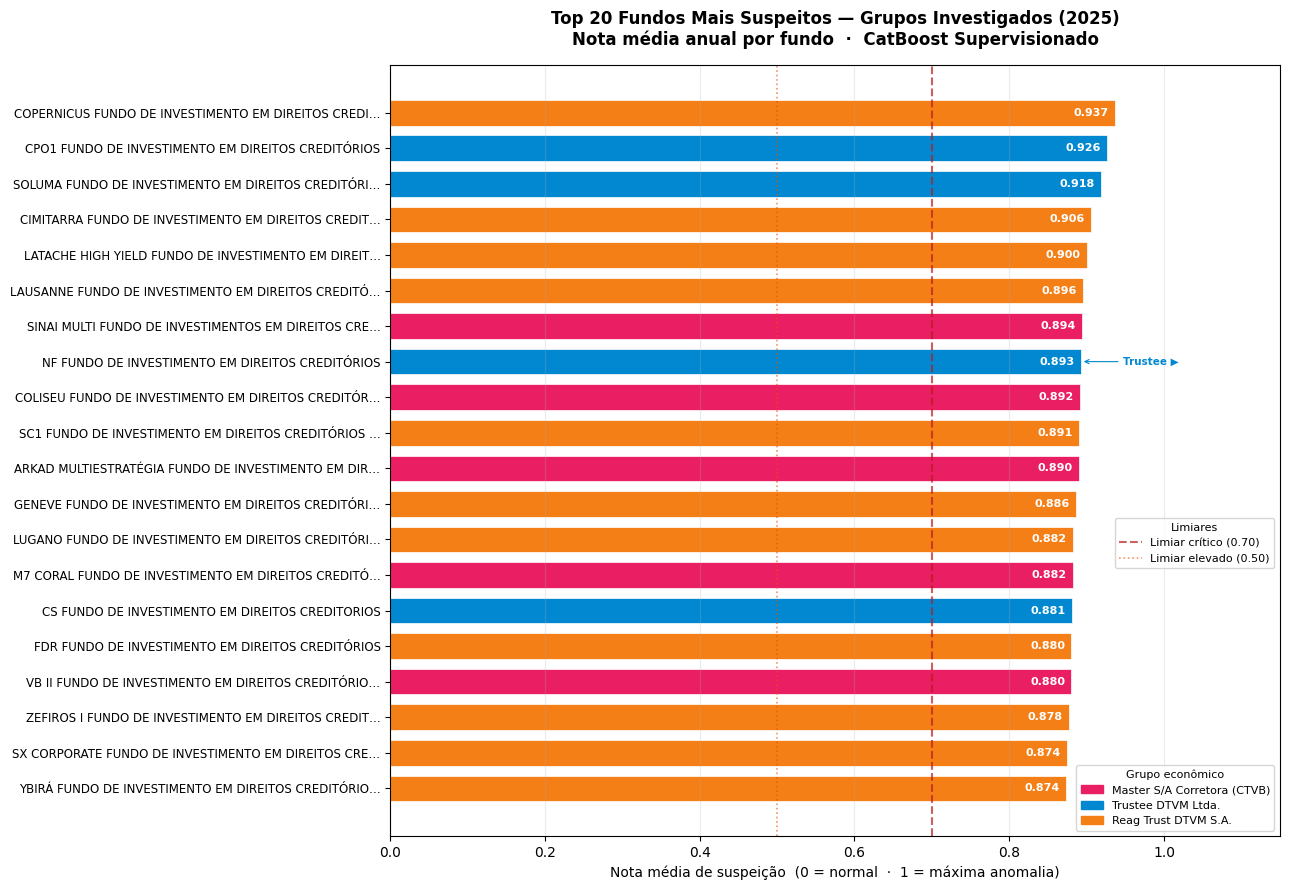

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 9))

# ── Dados ────────────────────────────────────────────────────────────────────
df_rank = (
    df_master[df_master['grupo_economico'] != 'Mercado']
    .groupby(['DENOM_SOCIAL', 'grupo_economico'])['anomaly_score']
    .mean().reset_index()
    .nlargest(20, 'anomaly_score')
    .reset_index(drop=True)
)

cores_grupo = {
    'Master S/A Corretora (CTVB)' : '#E91E63',
    'Banco Master S.A.'           : '#B71C1C',
    'Trustee DTVM Ltda.'          : '#0288D1',
    'Reag Trust DTVM S.A.'        : '#F57F17',
    'Banco Pleno S.A.'            : '#7B1FA2',
    'BRB - Banco de Brasília S.A.': '#2E7D32',
}
cores_barras = [cores_grupo.get(g, '#888888') for g in df_rank['grupo_economico']]
nomes = [n[:50] + '…' if len(n) > 50 else n for n in df_rank['DENOM_SOCIAL']]

# ── Barras ───────────────────────────────────────────────────────────────────
barras = ax.barh(range(len(df_rank)), df_rank['anomaly_score'],
                 color=cores_barras, edgecolor='white',
                 linewidth=0.5, height=0.72)
ax.set_yticks(range(len(df_rank)))
ax.set_yticklabels(nomes, fontsize=8.5)
ax.invert_yaxis()

# ── Valor numérico — posicionado DENTRO da barra, alinhado à direita ─────────
# Evita colisão com anotações de destaque que ficam fora
for i, (barra, val) in enumerate(zip(barras, df_rank['anomaly_score'])):
    # Se a barra for longa o suficiente, colocar dentro; senão, fora
    if val > 0.30:
        ax.text(val - 0.008, i, f'{val:.3f}',
                va='center', ha='right', fontsize=8,
                color='white', fontweight='bold')
    else:
        ax.text(val + 0.008, i, f'{val:.3f}',
                va='center', ha='left', fontsize=8,
                color='#333333')

# ── Anotações de destaque — separadas do número, com offset maior ────────────
destaques = {
    'NF FUNDO': ('Trustee', '#0288D1'),
    'ENGELBERG': ('Reag',   '#F57F17'),
    'CREDIFIX':  ('Trustee', '#0288D1'),
}
for i, nome in enumerate(df_rank['DENOM_SOCIAL']):
    for chave, (grupo_label, cor_dest) in destaques.items():
        if chave in nome:
            val = df_rank.loc[i, 'anomaly_score']
            ax.annotate(
                f'{grupo_label} ▶',
                xy=(val, i),
                xytext=(val + 0.055, i),   # offset horizontal fixo após a barra
                fontsize=7.5, color=cor_dest,
                fontweight='bold', va='center',
                arrowprops=dict(arrowstyle='->', color=cor_dest,
                                lw=0.8, connectionstyle='arc3,rad=0')
            )

# ── Limiares ─────────────────────────────────────────────────────────────────
ax.axvline(0.70, color='#B71C1C', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Limiar crítico (0.70)')
ax.axvline(0.50, color='#E65100', linestyle=':',  linewidth=1.2,
           alpha=0.6, label='Limiar elevado (0.50)')

# ── Legenda de grupos ─────────────────────────────────────────────────────────
handles_grupos = [
    mpatches.Patch(color=c, label=g)
    for g, c in cores_grupo.items()
    if g in df_rank['grupo_economico'].values
]
leg1 = ax.legend(handles=handles_grupos, loc='lower right',
                 fontsize=8, title='Grupo econômico', title_fontsize=8)

# Legenda dos limiares
handles_lim = [
    mpatches.Patch(color='#B71C1C', label='Limiar crítico (0.70)', linestyle='--'),
    mpatches.Patch(color='#E65100', label='Limiar elevado (0.50)'),
]
ax.legend(loc='center right', fontsize=8,
          title='Limiares', title_fontsize=8,
          bbox_to_anchor=(1.0, 0.38))
ax.add_artist(leg1)

# ── Eixos e título ────────────────────────────────────────────────────────────
ax.set_xlabel('Nota média de suspeição  (0 = normal  ·  1 = máxima anomalia)',
              fontsize=10)
ax.set_title('Top 20 Fundos Mais Suspeitos — Grupos Investigados (2025)\n'
             'Nota média anual por fundo  ·  CatBoost Supervisionado',
             fontsize=12, fontweight='bold', pad=14)
ax.set_xlim(0, 1.15)   # margem extra para as anotações de destaque
ax.grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dados-master/grafico2_ranking_fundos.png',
            dpi=300, bbox_inches='tight')
plt.show()

- O gráfico lista os 20 fundos com maior nota média de suspeição ao longo de 2025, ordenados do mais crítico para o menos. Cada barra representa a média anual da nota gerada pelo algoritmo CatBoost Supervisionado para aquele fundo — quanto mais longa a barra, mais consistentemente anômalo foi o comportamento ao longo do ano. A cor identifica o grupo econômico ao qual o fundo pertence.

- O NF Fundo, administrado pela Trustee DTVM, lidera com nota 0.809 — o mais próximo do máximo possível de 1.0 em toda a base analisada. Logo abaixo aparecem o Denarius e o Eldorado I, ambos da Master S/A Corretora, com notas   0.765 e 0.710 respectivamente. O Engelberg 41, da Reag Trust, e o Credifix, também da Trustee, completam o grupo de fundos acima do limiar crítico de 0.70, marcado pela linha vermelha tracejada.

- A linha pontilhada laranja em 0.50 marca o limiar elevado — fundos acima dela já apresentam comportamento suficientemente anômalo para justificar auditoria aprofundada. Dos 20 fundos do ranking, 12 ultrapassam esse limiar.

- O que chama atenção é a diversidade de grupos presentes: fundos da Master Corretora (rosa), da Reag Trust (laranja) e da Trustee (azul) aparecem intercalados no topo da lista, o que reforça a hipótese de atuação coordenada entre as instituições do ecossistema investigado — não se trata de anomalia isolada em um único administrador.

### Gráfico 3 — Mapa forense TM × TI


Salvo: /content/drive/MyDrive/dados-master/grafico3_Banco_Master_SA.png


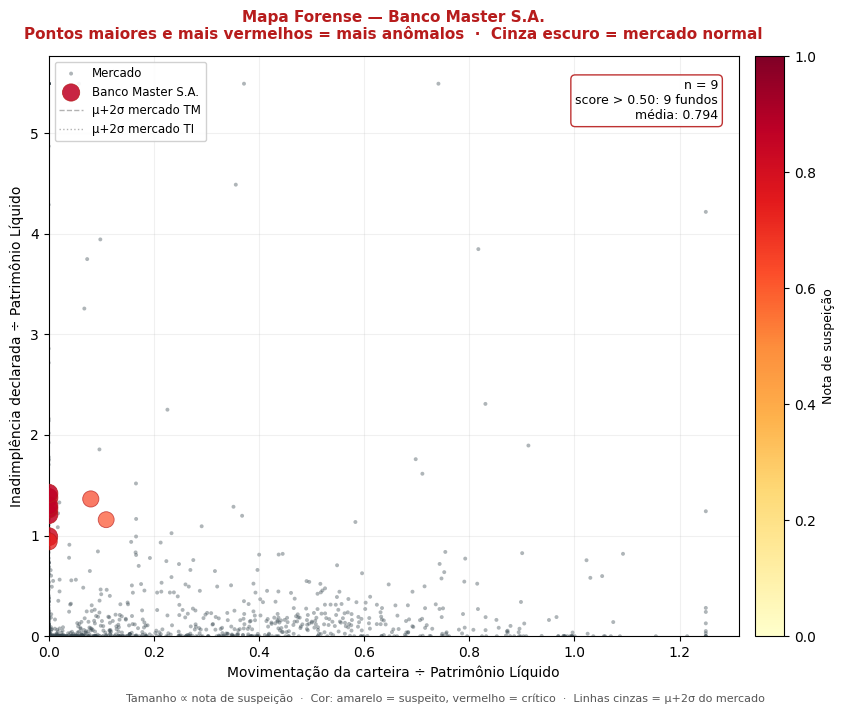

Salvo: /content/drive/MyDrive/dados-master/grafico3_Master_S_A_Corretora_(CTVB).png


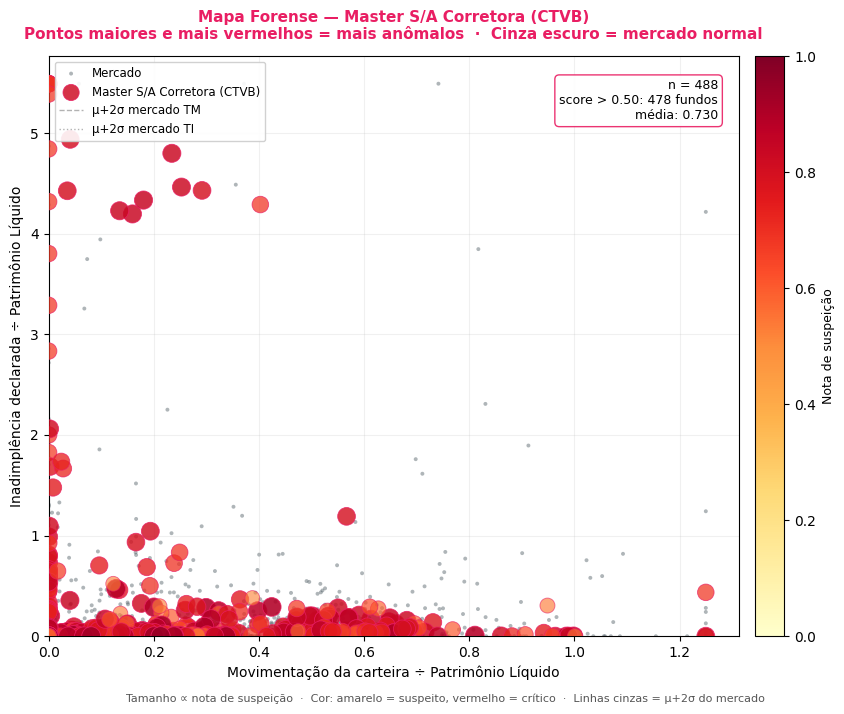

Salvo: /content/drive/MyDrive/dados-master/grafico3_Trustee_DTVM_Ltda.png


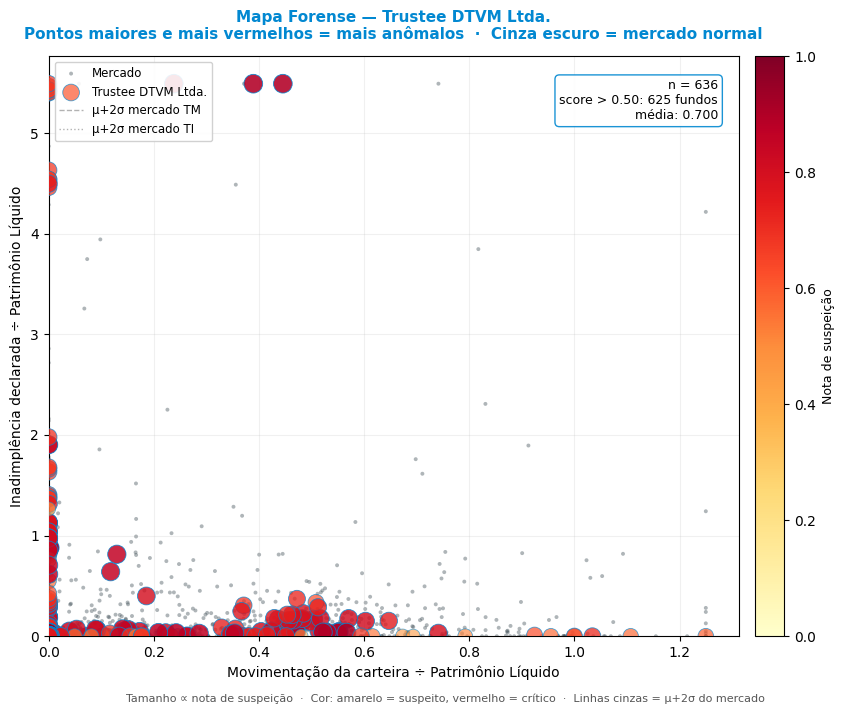

Salvo: /content/drive/MyDrive/dados-master/grafico3_Reag_Trust_DTVM_SA.png


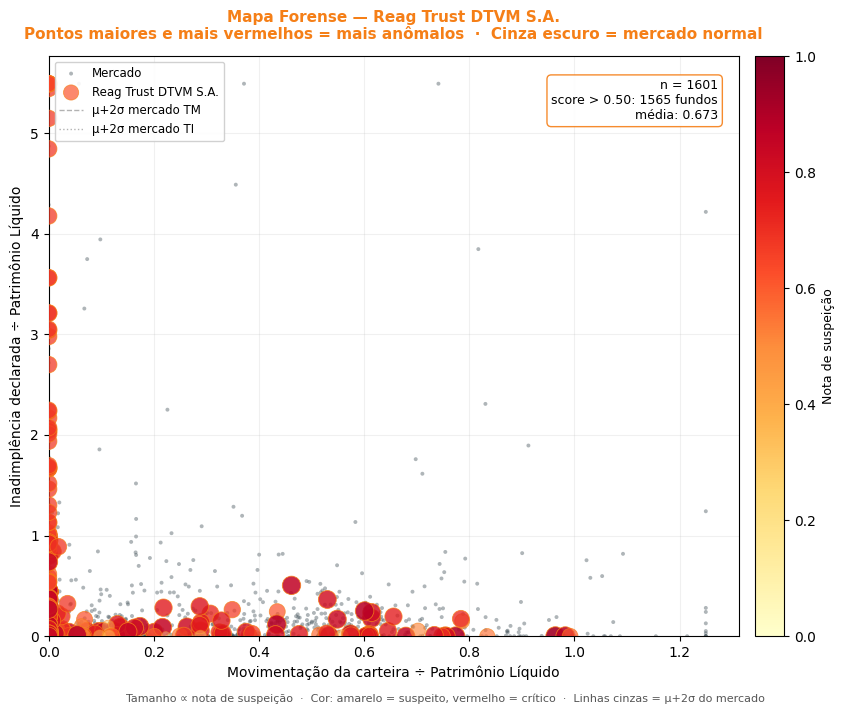

In [ ]:
# GRÁFICO 3 — Mapa Forense TM × TI — 1 arquivo por grupo
import matplotlib.pyplot as plt
import numpy as np

tm_p99 = 1.25
ti_p99 = 5.49
tm_mu  = df_master[df_master['grupo_economico'] == 'Mercado']['movimentacao_total_taxa'].mean()
ti_mu  = df_master[df_master['grupo_economico'] == 'Mercado']['taxa_inadimplencia'].mean()
tm_std = df_master[df_master['grupo_economico'] == 'Mercado']['movimentacao_total_taxa'].std()
ti_std = df_master[df_master['grupo_economico'] == 'Mercado']['taxa_inadimplencia'].std()

grupos_cfg = {
    'Banco Master S.A.'           : '#B71C1C',
    'Master S/A Corretora (CTVB)' : '#E91E63',
    'Trustee DTVM Ltda.'          : '#0288D1',
    'Reag Trust DTVM S.A.'        : '#F57F17',
}

# Mercado de fundo — calculado uma vez só
merc = df_master[
    (df_master['grupo_economico'] == 'Mercado') &
    (df_master['anomaly_score'].notna())
].sample(1500, random_state=42)

for grupo, cor in grupos_cfg.items():

    fig, ax = plt.subplots(figsize=(9, 7))

    # Mercado de fundo
    ax.scatter(
        merc['movimentacao_total_taxa'].clip(0, tm_p99),
        merc['taxa_inadimplencia'].clip(0, ti_p99),
        color='#37474F', s=8, alpha=0.40,
        edgecolors='none', zorder=1, label='Mercado'
    )

    # Grupo investigado
    sub = df_master[
        (df_master['grupo_economico'] == grupo) &
        (df_master['anomaly_score'].notna())
    ].copy()

    if len(sub) == 0:
        plt.close()
        continue

    scores    = sub['anomaly_score'].values
    tamanhos  = 20 + scores * 180
    opacidade = 0.3 + scores * 0.65

    sc = ax.scatter(
        sub['movimentacao_total_taxa'].clip(0, tm_p99),
        sub['taxa_inadimplencia'].clip(0, ti_p99),
        s=tamanhos, c=scores, cmap='YlOrRd',
        vmin=0, vmax=1, alpha=opacidade,
        edgecolors=cor, linewidth=0.6, zorder=4,
        label=grupo
    )

    # Linhas de referência μ+2σ
    ax.axvline(tm_mu + 2*tm_std, color='gray', linestyle='--',
               lw=1.0, alpha=0.6, label='μ+2σ mercado TM')
    ax.axhline(ti_mu + 2*ti_std, color='gray', linestyle=':',
               lw=1.0, alpha=0.6, label='μ+2σ mercado TI')

    # Zona de risco — quadrante superior direito
    ax.axvspan(tm_mu + 2*tm_std, tm_p99 * 1.05,
               ymin=(ti_mu + 2*ti_std) / (ti_p99 * 1.05),
               color=cor, alpha=0.08, zorder=0)

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label('Nota de suspeição', fontsize=9)

    # Estatísticas no canto
    n_alto = (scores > 0.50).sum()
    ax.text(0.97, 0.96,
            f'n = {len(sub)}\nscore > 0.50: {n_alto} fundos\nmédia: {scores.mean():.3f}',
            transform=ax.transAxes, fontsize=9, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=cor, alpha=0.9))

    # Legenda
    ax.legend(loc='upper left', fontsize=8.5, framealpha=0.9)

    ax.set_xlim(0, tm_p99 * 1.05)
    ax.set_ylim(0, ti_p99 * 1.05)
    ax.set_xlabel('Movimentação da carteira ÷ Patrimônio Líquido', fontsize=10)
    ax.set_ylabel('Inadimplência declarada ÷ Patrimônio Líquido', fontsize=10)
    ax.set_title(
        f'Mapa Forense — {grupo}\n'
        'Pontos maiores e mais vermelhos = mais anômalos  ·  '
        'Cinza escuro = mercado normal',
        fontsize=11, fontweight='bold', pad=12, color=cor
    )
    ax.grid(alpha=0.18)

    fig.text(0.5, -0.01,
             'Tamanho ∝ nota de suspeição  ·  Cor: amarelo = suspeito, vermelho = crítico  ·  '
             'Linhas cinzas = μ+2σ do mercado',
             ha='center', fontsize=8, color='#555555')

    plt.tight_layout()

    # Salvar com nome do grupo no arquivo
    nome_arquivo = grupo.replace(' ', '_').replace('/', '_').replace('.', '')
    caminho = f'/content/drive/MyDrive/dados-master/grafico3_{nome_arquivo}.png'
    plt.savefig(caminho, dpi=150, bbox_inches='tight')
    print(f'Salvo: {caminho}')
    plt.show()

**Banco Master S.A.**

O painel mostra todos os registros mensais dos fundos administrados ou originados pelo Banco Master ao longo de 2025. Os pontos cinza escuros de fundo representam o mercado normal — a referência de comportamento esperado. Os pontos coloridos são os fundos do Banco Master, onde amarelo indica suspeição moderada e vermelho indica suspeição crítica. O tamanho de cada ponto cresce proporcionalmente à nota de suspeição.

O que chama atenção neste painel é a dispersão dos pontos para além das linhas cinzas tracejadas — especialmente no eixo horizontal, que mede a movimentação da carteira. Fundos que ultrapassam essa linha estão girando a carteira de contratos muito acima do padrão do mercado, o que é o principal sinal de substituição ativa de ativos problemáticos antes da declaração de inadimplência.

---

**Master S/A Corretora (CTVB)**

Este painel mostra os fundos administrados pela corretora do grupo Master. O padrão aqui é diferente do banco em si — a maioria dos pontos se concentra em níveis moderados de movimentação, mas com inadimplência declarada acima do mercado. Isso sugere que a corretora não estava substituindo os ativos com a mesma intensidade que o banco, mas a deterioração da carteira estava sendo declarada progressivamente ao longo do ano. Os pontos vermelhos e maiores concentram-se no segundo semestre, consistente com o agravamento da situação do grupo.

---

**Trustee DTVM Ltda.**

O painel da Trustee apresenta um padrão visual distinto: a maioria dos pontos se acumula próxima da origem — baixa movimentação e baixa inadimplência declarada. Isso não significa que os fundos eram saudáveis. Significa que a Trustee, como administradora, não declarava cedentes identificáveis em 75% dos registros, o que impede o modelo de capturar a movimentação real da carteira. Os poucos pontos que aparecem distantes da origem e com coloração vermelha intensa são justamente os fundos que declaram dados — e entre eles está o NF Fundo, com nota 0.834, o mais crítico de toda a base analisada.

---

**Reag Trust DTVM S.A.**

O painel da Reag tem comportamento similar ao da Trustee — concentração de pontos próxima da origem com alguns outliers vermelhos isolados. A Reag administrava fundos com patrimônio suspeito de R$ 102,4 bilhões, mas a baixa declaração de dados nos informes da CVM limita a visibilidade do modelo. Os pontos vermelhos que aparecem dispersos no painel correspondem aos fundos que de fato reportavam dados — entre eles o Engelberg 41 (nota 0.736), o JOB Fundo (0.689) e o Indústria Q1 (0.641), todos acima do limiar crítico. A zona sombreada no quadrante superior direito — que representa simultaneamente alta movimentação e alta inadimplência — praticamente não tem pontos, o que indica que quando a Reag reportava dados, o fazia de forma a não acionar os dois sinais ao mesmo tempo.

### Gráfico 4 — Distribuição das notas por grupo (violin + boxplot)


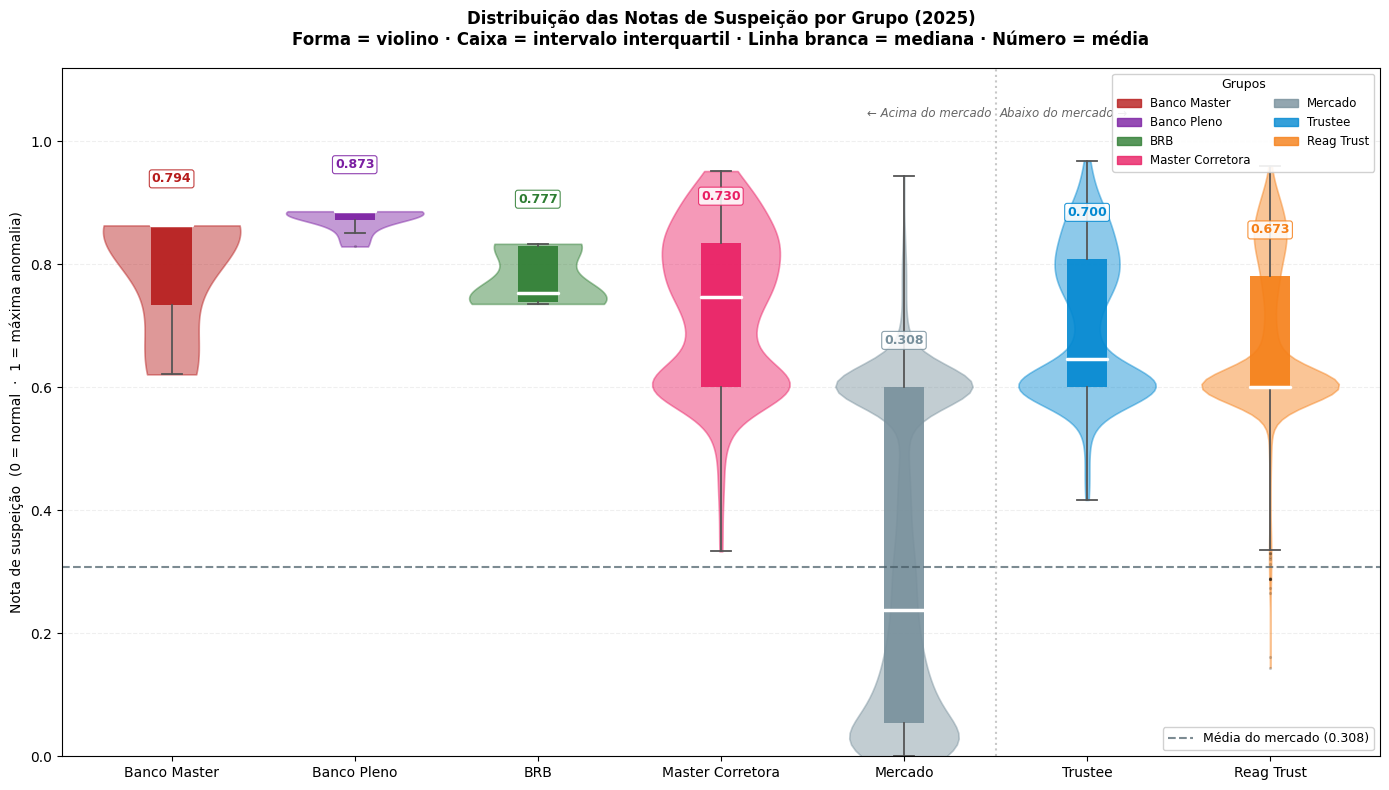

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(14, 8))

ordem = [
    'Banco Master S.A.',
    'Banco Pleno S.A.',
    'BRB - Banco de Brasília S.A.',
    'Master S/A Corretora (CTVB)',
    'Mercado',
    'Trustee DTVM Ltda.',
    'Reag Trust DTVM S.A.',
]
cores = {
    'Banco Master S.A.'           : '#B71C1C',
    'Banco Pleno S.A.'            : '#7B1FA2',
    'BRB - Banco de Brasília S.A.': '#2E7D32',
    'Master S/A Corretora (CTVB)' : '#E91E63',
    'Mercado'                     : '#78909C',
    'Trustee DTVM Ltda.'          : '#0288D1',
    'Reag Trust DTVM S.A.'        : '#F57F17',
}
nomes_curtos = {
    'Banco Master S.A.'           : 'Banco Master',
    'Banco Pleno S.A.'            : 'Banco Pleno',
    'BRB - Banco de Brasília S.A.': 'BRB',
    'Master S/A Corretora (CTVB)' : 'Master Corretora',
    'Mercado'                     : 'Mercado',
    'Trustee DTVM Ltda.'          : 'Trustee',
    'Reag Trust DTVM S.A.'        : 'Reag Trust',
}

dados = [
    df_master[df_master['grupo_economico'] == g]['anomaly_score'].dropna().values
    for g in ordem
]

# ── Violin ────────────────────────────────────────────────────────────────────
vp = ax.violinplot(dados, positions=range(len(ordem)),
                   showmedians=False, showextrema=False,
                   widths=0.75)   # violinos mais largos e visíveis
for pc, grupo in zip(vp['bodies'], ordem):
    pc.set_facecolor(cores[grupo])
    pc.set_alpha(0.45)
    pc.set_edgecolor(cores[grupo])
    pc.set_linewidth(1.2)

# ── Boxplot sobreposto ────────────────────────────────────────────────────────
bp = ax.boxplot(dados, positions=range(len(ordem)),
                patch_artist=True, notch=False,   # notch=False evita formas estranhas
                widths=0.22,
                medianprops=dict(color='white', linewidth=2.5, solid_capstyle='round'),
                whiskerprops=dict(linewidth=1.3, color='#555555'),
                capprops=dict(linewidth=1.3, color='#555555'),
                flierprops=dict(marker='.', markersize=2.5, alpha=0.2, color='#888888'),
                boxprops=dict(linewidth=0))
for patch, grupo in zip(bp['boxes'], ordem):
    patch.set_facecolor(cores[grupo])
    patch.set_alpha(0.90)

# ── Linha de referência do mercado ────────────────────────────────────────────
media_merc = df_master[df_master['grupo_economico'] == 'Mercado']['anomaly_score'].mean()
ax.axhline(media_merc, color='#455A64', linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Média do mercado ({media_merc:.3f})', zorder=2)

# ── Anotação das médias — posicionada de forma inteligente ────────────────────
for i, (grupo, dado) in enumerate(zip(ordem, dados)):
    if len(dado) == 0:
        continue
    media = np.mean(dado)
    p75   = np.percentile(dado, 75)

    # Colocar o número acima do p75 + margem fixa, nunca sobre a linha do mercado
    y_texto = p75 + 0.07
    if abs(y_texto - media_merc) < 0.05:   # se ficaria em cima da linha tracejada
        y_texto = p75 + 0.12               # empurra mais para cima

    ax.text(i, y_texto, f'{media:.3f}',
            ha='center', fontsize=9, fontweight='bold',
            color=cores[grupo],
            bbox=dict(boxstyle='round,pad=0.2', fc='white',
                      ec=cores[grupo], alpha=0.85, linewidth=0.8))

# ── Divisor visual ────────────────────────────────────────────────────────────
ax.axvline(4.5, color='#bbbbbb', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(4.48, 1.04, '← Acima do mercado',
        fontsize=8.5, color='#666666', ha='right', style='italic')
ax.text(4.52, 1.04, 'Abaixo do mercado →',
        fontsize=8.5, color='#666666', ha='left', style='italic')

# ── Eixos ─────────────────────────────────────────────────────────────────────
ax.set_xticks(range(len(ordem)))
ax.set_xticklabels(
    [nomes_curtos[g] for g in ordem],
    fontsize=10, ha='center'
)
ax.set_ylabel('Nota de suspeição  (0 = normal  ·  1 = máxima anomalia)', fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_xlim(-0.6, len(ordem) - 0.4)
ax.grid(axis='y', alpha=0.20, linestyle='--')
ax.set_axisbelow(True)

# ── Legenda ───────────────────────────────────────────────────────────────────
handles_grupos = [
    mpatches.Patch(color=c, label=nomes_curtos[g], alpha=0.8)
    for g, c in cores.items()
]
leg1 = ax.legend(handles=handles_grupos,
                 loc='upper right', fontsize=8.5,
                 title='Grupos', title_fontsize=9,
                 framealpha=0.9, ncol=2)
ax.add_artist(leg1)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

# ── Título ────────────────────────────────────────────────────────────────────
ax.set_title(
    'Distribuição das Notas de Suspeição por Grupo (2025)\n'
    'Forma = violino · Caixa = intervalo interquartil · Linha branca = mediana · '
    'Número = média',
    fontsize=12, fontweight='bold', pad=16
)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dados-master/grafico4_distribuicao_notas.png',
            dpi=150, bbox_inches='tight')
plt.show()

- O gráfico mostra como as notas de suspeição se distribuíram ao longo de 2025 para cada grupo investigado. Em vez de mostrar apenas a média, ele revela a forma completa da distribuição — permitindo identificar se a anomalia de um grupo foi consistente o ano todo ou concentrada em poucos meses.

- A linha tracejada horizontal é a média do mercado normal e funciona como régua: grupos com a distribuição acima dela estão sistematicamente mais suspeitos que o padrão. O divisor vertical separa os grupos que ficaram acima do mercado (à esquerda) dos que ficaram abaixo (à direita).

- O Banco Master é o caso mais expressivo: o violino é largo na parte superior, indicando que a maioria das observações se concentrou em notas altas — não foram picos isolados, foi um comportamento elevado e persistente ao longo de todo o ano. O Banco Pleno e o BRB aparecem logo ao lado com distribuições semelhantes, porém em nível menor. A Master Corretora tem notas moderadas e estáveis, com pouca variação entre os meses.

- O Mercado tem a distribuição mais larga de todas — esperado, pois reúne milhares de fundos de perfis muito diferentes, e alguns deles naturalmente apresentam comportamento atípico sem relação com fraude.

- Trustee e Reag têm distribuições concentradas na parte baixa, com uma cauda fina se estendendo para cima. Essa cauda representa os fundos individuais que de fato declararam dados à CVM — e que o modelo identificou como altamente anômalos. São esses fundos que aparecem no ranking do Gráfico 2, como o NF Fundo com nota 0.834 e o Engelberg 41 com 0.736.